In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report

train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/FruitinAmazon/train"
image_size = (224, 224)
batch_size = 32



In [12]:
class_names = sorted(os.listdir(train_dir))
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

print(f"Corrupted images found: {len(corrupted_images)}")



Corrupted images found: 0


In [13]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])


Found 56 files belonging to 6 classes.
Using 45 files for training.
Using 11 files for validation.


In [14]:
num_classes = len(class_names)

model = Sequential([

    layers.Input(shape=(image_size[0], image_size[1], 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,32

 Total params: 51,610,822 (196.88 MB)

 Trainable params: 51,608,838 (196.87 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.2667 - loss: 1.9125 - val_accuracy: 0.1818 - val_loss: 2.1492
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.6000 - loss: 1.1013 - val_accuracy: 0.2727 - val_loss: 1.8493
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.6444 - loss: 0.9973 - val_accuracy: 0.0909 - val_loss: 1.8532
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6667 - loss: 0.6912 - val_accuracy: 0.0909 - val_loss: 2.0571
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.7778 - loss: 0.7291 - val_accuracy: 0.0909 - val_loss: 2.2552
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6889 - loss: 0.8483 - val_accuracy: 0.0909 - val_loss: 2.3848
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.6889 - loss: 0.7098 - val_accuracy: 0.0909 - val_loss: 2.3834
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7111 - loss: 0.8850 - val_accuracy: 0.1818 - val_loss: 2.4735
Epoch 9/

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)

output = layers.Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

vgg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])





In [17]:
print("Starting VGG16 Transfer Learning Training...")
vgg_history = vgg_model.fit(train_ds, validation_data=val_ds, epochs=5)


print("\nGenerating Classification Report...")


y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, labels=list(range(num_classes))))

Starting VGG16 Transfer Learning Training...
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 18s/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.7273 - val_loss: 1.5235
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 78s 17s/step - accuracy: 1.0000 - loss: 1.9468e-04 - val_accuracy: 0.8182 - val_loss: 1.3033
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 18s/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.8182 - val_loss: 1.1092
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 17s/step - accuracy: 0.9778 - loss: 0.0346 - val_accuracy: 0.8182 - val_loss: 0.8283
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 17s/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.7273 - val_loss: 0.6618

Generating Classification Report...
              precision    recall  f1-score   support

        acai       1.00      0.50      0.67         2
     cupuacu       0.67      1.00      0.80         4
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

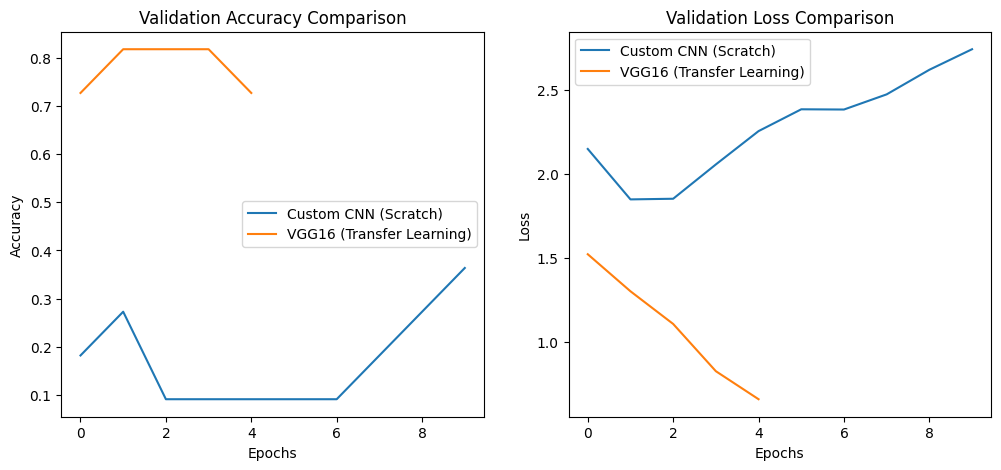

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Custom CNN (Scratch)')
plt.plot(vgg_history.history['val_accuracy'], label='VGG16 (Transfer Learning)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Custom CNN (Scratch)')
plt.plot(vgg_history.history['val_loss'], label='VGG16 (Transfer Learning)')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()